# Bellabeat Case Study Notebook

This notebook follows the Bellabeat case study structure for the project defined by the Google Data Analytics Capstone course on Coursera:

1. Ask  
2. Prepare  
3. Process  
4. Analyze  
5. Share  
6. Act  

The main goal is to identify trends in smart device usage and use them to make marketing recommendations for Bellabeat.

## 1. Ask

### Business task
Bellabeat wants to understand how people use smart fitness devices and to use those insights to improve marketing for one of its products.

### Guiding questions
1. What are some trends in smart device usage?
2. How could these trends apply to Bellabeat customers?
3. How could these trends help influence Bellabeat's marketing strategy?

### Product focus
For this notebook, I will focus on **Bellabeat Leaf**.

## 2. Prepare

### Data source
This notebook uses Fitbit fitness tracker data downloaded from Kaggle at the following URL:

https://www.kaggle.com/datasets/arashnic/fitbit

### Files used
- `dailyActivity_merged.csv`
   * *Note: There are two of these files for the time period of 3.12.16-4.11.16 and 4.12.16-5.12.16*
- `sleepDay_merged.csv`
   * *Note: There is only one file for the time period of 4.12.16-5.12.16*

### Notes about the data
Some limitations of this dataset:
- This data contains a small sample size
- Not all users have sleep data and from only one time period
- There is limited background information about users

Because of these limitations, the results should be treated as helpful patterns, not final proof about all Bellabeat customers.

In [1]:
# Import packages
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
# Optional setting so tables are easier to read
pd.set_option("display.max_columns", None)

## 3. Process

In this section I will:
- load the files
- inspect the data
- clean date columns
- check duplicates
- create a daily combined table

In [3]:
# Load data
activity_1 = pd.read_csv("archive/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/dailyActivity_merged.csv")
activity_2 = pd.read_csv("archive/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/dailyActivity_merged.csv")
sleep = pd.read_csv("archive/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/sleepDay_merged.csv")

activity = pd.concat([activity_1, activity_2], ignore_index=True)

print("Activity shape:", activity.shape)
print("Sleep shape:", sleep.shape)

Activity shape: (1397, 15)
Sleep shape: (413, 5)


In [4]:
# Preview the data
activity.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,3/25/2016,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,33,12,205,804,1819
1,1503960366,3/26/2016,17609,11.55,11.55,0.0,6.92,0.73,3.91,0.0,89,17,274,588,2154
2,1503960366,3/27/2016,12736,8.53,8.53,0.0,4.66,0.16,3.71,0.0,56,5,268,605,1944
3,1503960366,3/28/2016,13231,8.93,8.93,0.0,3.19,0.79,4.95,0.0,39,20,224,1080,1932
4,1503960366,3/29/2016,12041,7.85,7.85,0.0,2.16,1.09,4.61,0.0,28,28,243,763,1886


In [5]:
sleep.head()

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,4/12/2016 12:00:00 AM,1,327,346
1,1503960366,4/13/2016 12:00:00 AM,2,384,407
2,1503960366,4/15/2016 12:00:00 AM,1,412,442
3,1503960366,4/16/2016 12:00:00 AM,2,340,367
4,1503960366,4/17/2016 12:00:00 AM,1,700,712


In [6]:
# Check column names
print("Activity columns:")
print(activity.columns.tolist())

print("\nSleep columns:")
print(sleep.columns.tolist())

Activity columns:
['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance', 'LoggedActivitiesDistance', 'VeryActiveDistance', 'ModeratelyActiveDistance', 'LightActiveDistance', 'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories']

Sleep columns:
['Id', 'SleepDay', 'TotalSleepRecords', 'TotalMinutesAsleep', 'TotalTimeInBed']


In [7]:
# Convert date columns to datetime
activity["ActivityDate"] = pd.to_datetime(activity["ActivityDate"])
sleep["SleepDay"] = pd.to_datetime(sleep["SleepDay"])

# Create a date-only column in sleep so it can be joined to activity
sleep["ActivityDate"] = sleep["SleepDay"].dt.date
activity["ActivityDate_only"] = activity["ActivityDate"].dt.date

/var/folders/q0/mwttt0tx0h7gbr01gw2hk8640000gn/T/ipykernel_48473/2812228736.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sleep["SleepDay"] = pd.to_datetime(sleep["SleepDay"])


In [8]:
# Check duplicates
print("Duplicate rows in activity:", activity.duplicated().sum())
print("Duplicate rows in sleep:", sleep.duplicated().sum())

# Remove duplicates if any exist
activity = activity.drop_duplicates()
sleep = sleep.drop_duplicates()

Duplicate rows in activity: 0
Duplicate rows in sleep: 3


In [9]:
# Check missing values
print("Missing values in activity:")
print(activity.isna().sum())

print("\nMissing values in sleep:")
print(sleep.isna().sum())

Missing values in activity:
Id                          0
ActivityDate                0
TotalSteps                  0
TotalDistance               0
TrackerDistance             0
LoggedActivitiesDistance    0
VeryActiveDistance          0
ModeratelyActiveDistance    0
LightActiveDistance         0
SedentaryActiveDistance     0
VeryActiveMinutes           0
FairlyActiveMinutes         0
LightlyActiveMinutes        0
SedentaryMinutes            0
Calories                    0
ActivityDate_only           0
dtype: int64

Missing values in sleep:
Id                    0
SleepDay              0
TotalSleepRecords     0
TotalMinutesAsleep    0
TotalTimeInBed        0
ActivityDate          0
dtype: int64


In [10]:
# Select a few columns from sleep for a simpler join
sleep_small = sleep[["Id", "ActivityDate", "TotalSleepRecords", "TotalMinutesAsleep", "TotalTimeInBed"]].copy()

# Join activity and sleep together
daily_data = pd.merge(
    activity,
    sleep_small,
    left_on=["Id", "ActivityDate_only"],
    right_on=["Id", "ActivityDate"],
    how="left"
)

daily_data.head()

,Id,ActivityDate_x,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,ActivityDate_only,ActivityDate_y,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,2016-03-25,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,33,12,205,804,1819,2016-03-25,NaN,NaN,NaN,NaN
1,1503960366,2016-03-26,17609,11.55,11.55,0.0,6.92,0.73,3.91,0.0,89,17,274,588,2154,2016-03-26,NaN,NaN,NaN,NaN
2,1503960366,2016-03-27,12736,8.53,8.53,0.0,4.66,0.16,3.71,0.0,56,5,268,605,1944,2016-03-27,NaN,NaN,NaN,NaN
3,1503960366,2016-03-28,13231,8.93,8.93,0.0,3.19,0.79,4.95,0.0,39,20,224,1080,1932,2016-03-28,NaN,NaN,NaN,NaN
4,1503960366,2016-03-29,12041,7.85,7.85,0.0,2.16,1.09,4.61,0.0,28,28,243,763,1886,2016-03-29,NaN,NaN,NaN,NaN


In [11]:
# Create a weekday column
daily_data["weekday"] = pd.to_datetime(daily_data["ActivityDate_x"]).dt.day_name()

# Create a simple sleep efficiency column
daily_data["sleep_efficiency"] = (
    daily_data["TotalMinutesAsleep"] / daily_data["TotalTimeInBed"]
) * 100

daily_data.head()

,Id,ActivityDate_x,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,ActivityDate_only,ActivityDate_y,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed,weekday,sleep_efficiency
0,1503960366,2016-03-25,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,33,12,205,804,1819,2016-03-25,NaN,NaN,NaN,NaN,Friday,NaN
1,1503960366,2016-03-26,17609,11.55,11.55,0.0,6.92,0.73,3.91,0.0,89,17,274,588,2154,2016-03-26,NaN,NaN,NaN,NaN,Saturday,NaN
2,1503960366,2016-03-27,12736,8.53,8.53,0.0,4.66,0.16,3.71,0.0,56,5,268,605,1944,2016-03-27,NaN,NaN,NaN,NaN,Sunday,NaN
3,1503960366,2016-03-28,13231,8.93,8.93,0.0,3.19,0.79,4.95,0.0,39,20,224,1080,1932,2016-03-28,NaN,NaN,NaN,NaN,Monday,NaN
4,1503960366,2016-03-29,12041,7.85,7.85,0.0,2.16,1.09,4.61,0.0,28,28,243,763,1886,2016-03-29,NaN,NaN,NaN,NaN,Tuesday,NaN


## 4. Load Data into SQLite

Now I will load the cleaned tables into SQLite so I utilize both Python and SQL to answer different parts of the case study in Section 5 *Analyze*.

In [12]:
# Create SQLite database in memory
conn = sqlite3.connect(":memory:")

# Save tables to SQLite
activity.to_sql("activity", conn, if_exists="replace", index=False)
sleep_small.to_sql("sleep", conn, if_exists="replace", index=False)
daily_data.to_sql("daily_data", conn, if_exists="replace", index=False)

1397

In [13]:
# Show tables in the database
query = "SELECT name FROM sqlite_master WHERE type='table';"
pd.read_sql_query(query, conn)

,name
0,activity
1,sleep
2,daily_data


## 5. Analyze

In this section, I will use both Python and SQL to answer the case study's guiding questions. As you will see in the following steps, I will use both SQL and Python to make equivalent calculations to compare the usage of both programming languages. Also, I will use Python to run correlation tests and to define a function to separate the individuals into categories of "Low", "Moderate", and "High" activity groups.

In [14]:
# Basic summary statistics in Python
daily_data[[
    "TotalSteps",
    "TotalDistance",
    "Calories",
    "SedentaryMinutes",
    "VeryActiveMinutes",
    "TotalMinutesAsleep",
    "TotalTimeInBed"
]].describe()

,TotalSteps,TotalDistance,Calories,SedentaryMinutes,VeryActiveMinutes,TotalMinutesAsleep,TotalTimeInBed
count,1397.000000,1397.000000,1397.000000,1397.000000,1397.000000,422.000000,422.000000
mean,7280.898354,5.219434,2266.265569,992.542591,19.679313,419.874408,459.184834
std,5214.336113,3.994206,753.005527,313.297376,31.675878,118.677574,127.024934
min,0.000000,0.000000,0.000000,0.000000,0.000000,58.000000,61.000000
25%,3146.000000,2.170000,1799.000000,729.000000,0.000000,361.000000,403.750000
50%,6999.000000,4.950000,2114.000000,1057.000000,2.000000,432.500000,463.500000
75%,10544.000000,7.500000,2770.000000,1244.000000,30.000000,491.500000,526.000000
max,36019.000000,28.030001,4900.000000,1440.000000,210.000000,796.000000,961.000000


In [15]:
# Average daily values
daily_data[[
    "TotalSteps",
    "Calories",
    "SedentaryMinutes",
    "VeryActiveMinutes",
    "TotalMinutesAsleep"
]].mean()

TotalSteps            7280.898354
Calories              2266.265569
SedentaryMinutes       992.542591
VeryActiveMinutes       19.679313
TotalMinutesAsleep     419.874408
dtype: float64

In [16]:
# Average steps and calories by weekday using SQL
query = '''
SELECT
    weekday,
    ROUND(AVG(TotalSteps), 2) AS avg_steps,
    ROUND(AVG(Calories), 2) AS avg_calories
FROM daily_data
GROUP BY weekday
ORDER BY avg_steps DESC;
'''
weekday_summary = pd.read_sql_query(query, conn)
weekday_summary

,weekday,avg_steps,avg_calories
0,Saturday,7752.27,2325.80
1,Wednesday,7547.58,2320.76
2,Monday,7541.32,2298.40
3,Thursday,7268.30,2223.75
4,Friday,7187.53,2325.10
5,Tuesday,7083.51,2156.94
6,Sunday,6606.73,2227.41


In [17]:
# Average sleep values using SQL
query = '''
SELECT
    ROUND(AVG(TotalMinutesAsleep), 2) AS avg_minutes_asleep,
    ROUND(AVG(TotalTimeInBed), 2) AS avg_time_in_bed
FROM daily_data;
'''
pd.read_sql_query(query, conn)

,avg_minutes_asleep,avg_time_in_bed
0,419.87,459.18


In [18]:
# Relationship between steps and calories using Python
daily_data[["TotalSteps", "Calories"]].corr()

,TotalSteps,Calories
TotalSteps,1.00000,0.59016
Calories,0.59016,1.00000


In [19]:
# Relationship between sleep and steps using Python
daily_data[["TotalSteps", "TotalMinutesAsleep"]].corr()

,TotalSteps,TotalMinutesAsleep
TotalSteps,1.00000,-0.19328
TotalMinutesAsleep,-0.19328,1.00000


In [20]:
# Count number of unique users using SQL
query = '''
SELECT COUNT(DISTINCT Id) AS unique_users
FROM activity;
'''
pd.read_sql_query(query, conn)

,unique_users
0,35


In [21]:
# Simple activity groups
def step_group(steps):
    if steps < 5000:
        return "Low activity"
    elif steps < 10000:
        return "Moderate activity"
    else:
        return "High activity"

daily_data["activity_group"] = daily_data["TotalSteps"].apply(step_group)

daily_data["activity_group"].value_counts()

activity_group
Low activity         500
Moderate activity    467
High activity        430
Name: count, dtype: int64

## 6. Share

In this section, I create a few visualizations to support the main findings of this case study using *matplotlib* in Python.

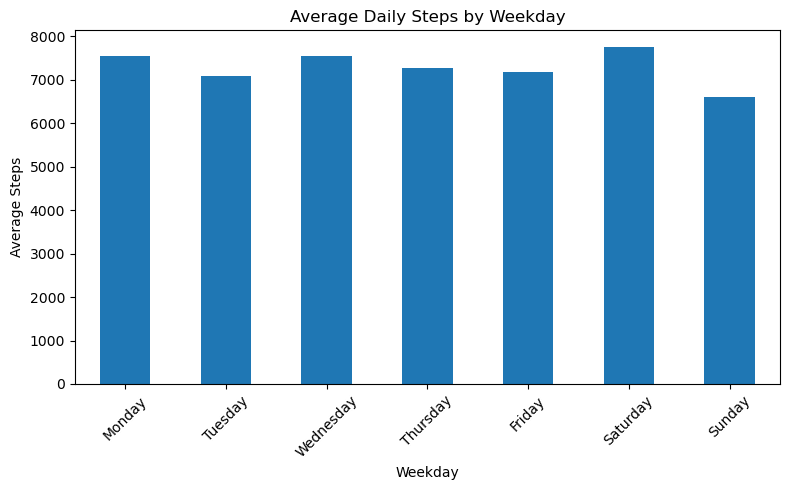

In [22]:
# Plot 1: Average steps by weekday
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_plot = daily_data.groupby("weekday")["TotalSteps"].mean().reindex(weekday_order)

plt.figure(figsize=(8,5))
weekday_plot.plot(kind="bar")
plt.title("Average Daily Steps by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average Steps")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

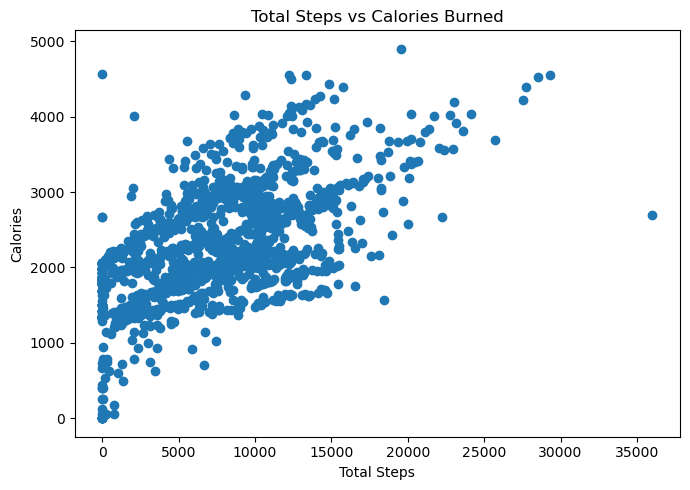

In [23]:
# Plot 2: Steps vs Calories
plt.figure(figsize=(7,5))
plt.scatter(daily_data["TotalSteps"], daily_data["Calories"])
plt.title("Total Steps vs Calories Burned")
plt.xlabel("Total Steps")
plt.ylabel("Calories")
plt.tight_layout()
plt.show()

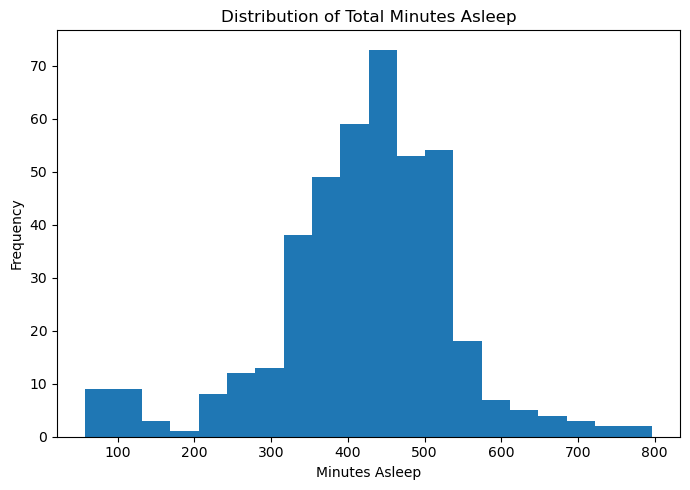

In [24]:
# Plot 3: Minutes asleep distribution
plt.figure(figsize=(7,5))
daily_data["TotalMinutesAsleep"].dropna().plot(kind="hist", bins=20)
plt.title("Distribution of Total Minutes Asleep")
plt.xlabel("Minutes Asleep")
plt.tight_layout()
plt.show()

## 7. Key Findings

After reviewing the summary statistics, calculations, and charts, these are the main findings:

1. **Users show different activity levels.**  
- Some users are highly active, but many users fall into low or moderate activity ranges.

2. **More steps usually means more calories burned.**  
- The relationship between steps and calories is positive, which makes sense and supports using steps as a simple activity measure.

3. **Daily routines may change by weekday.**  
- Average steps are not the same every day, which suggests that user behavior changes, even though the change is small, across the week.

4. **The dataset gives useful patterns, but it is limited.**  
- The sample is small, especially for the sleep activity, and the users may not represent all Bellabeat customers.

## 8. Act

### Recommendations for Bellabeat Leaf

**1. Focus marketing on habit building.**  
- Many users are not highly active every day, so Bellabeat can market Leaf as a tool that helps users build better daily routines over time.

**2. Highlight the connection between activity and overall wellness.**  
- Because activity trends are easy to see in the data, Bellabeat can show how Leaf helps users connect movement, sleep, and wellness using this product.

**3. Use personalized marketing messages.**  
- Since users seem to have different activity patterns, Bellabeat can create different messages for low-, moderate-, and high-activity users.

## 9. Final Answers to the Guiding Questions

### 1. What are some trends in smart device usage?
- Users have different activity levels.
- Higher step counts are linked with higher calories burned.
- User behavior can vary across weekdays.

### 2. How could these trends apply to Bellabeat customers?
These trends suggest Bellabeat customers may also benefit from tools that track daily activity, sleep, and overall routine patterns.

### 3. How could these trends help influence Bellabeat marketing strategy?
Bellabeat can use these insights to market Leaf as a product that supports habit building, daily movement, and personalized wellness tracking.

In [25]:
# Optional: save final combined dataset
daily_data.to_csv("bellabeat_daily_data_cleaned.csv", index=False)

Saved: bellabeat_daily_data_cleaned.csv
